In [1]:
import pandas as pd

# Загрузка
train = pd.read_parquet('train.parquet')
items = pd.read_parquet('benchmark_items.parquet')
queries = pd.read_parquet('benchmark_queries.parquet')


In [2]:
print(train.head(3).T)

                                                                           0  \
search_query                                              скупка телевизоров   
search_location_id                                                    652430   
search_is_delivery_search                                                  0   
search_infm_params_text                                                        
search_category                                                          114   
item_title_raw                                            Скупка б/у техники   
item_rating_reviews_count                                               91.0   
item_rating                                                         4.989011   
item_price                                                 1.000000000000000   
item_microcat_id                                                     2303374   
item_longitude                                            39.712818145751953   
item_location_id                        

In [3]:
train_cats = set(train['search_category'].unique())
test_cats = set(queries['search_category'].unique())
print(f"Категорий в тесте, которых нет в трейне: {len(test_cats - train_cats)}")

Категорий в тесте, которых нет в трейне: 0


In [4]:
import numpy as np


train['item_price'] = train['item_price'].astype(float)


def add_negative_samples(df, items_pool, n_neg=5):
    samples = []
    # Предварительно индексируем для быстрого поиска
    items_dict = items_pool.set_index('item_id')

    for idx, row in df.iterrows():

        samples.append({'query': row['search_query'], 'item_id': row['item_id'], 'target': 1, 'cat': row['search_category']})

        tokenized_query = row['search_query'].lower().split()
        scores = bm25.get_scores(tokenized_query)

        top_indices = np.argsort(scores)[::-1][:200]
        candidate_ids = items_pool.iloc[top_indices]['item_id'].values

        # Фильтруем: не берем тот товар, который пользователь на самом деле выбрал
        hard_neg_candidates = [cid for cid in candidate_ids if cid != row['item_id']]

        chosen_neg = np.random.choice(hard_neg_candidates, min(len(hard_neg_candidates), n_neg), replace=False)

        for neg_item in chosen_neg:
            samples.append({'query': row['search_query'], 'item_id': neg_item, 'target': 0, 'cat': row['search_category']})

    return pd.DataFrame(samples)


In [5]:
pip install rank-bm25

In [6]:
from rank_bm25 import BM25Okapi
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Преобразуем заголовки в список списков слов
tokenized_corpus = [doc.lower().split() for doc in items['item_title_raw']]

bm25 = BM25Okapi(tokenized_corpus)

# Векторизуем заголовки перед использованием функции
vectorizer = TfidfVectorizer().fit(items['item_title_raw'])
tfidf_matrix = vectorizer.transform(items['item_title_raw'])

def get_candidates(search_row, n=500):
    cat_id = search_row['search_category']
    subset = items[items['item_category_id'] == cat_id]

    # BM25 (поиск по словам)
    scores = bm25.get_scores(search_row['search_query'].lower().split())
    top_bm25_idx = np.argsort(scores)[::-1][:200]
    cands_bm25 = items.iloc[top_bm25_idx]['item_id'].values

    # TF-IDF (смысловой поиск)
    query_vec = vectorizer.transform([search_row['search_query']])
    sim_scores = cosine_similarity(query_vec, tfidf_matrix).flatten()
    top_tfidf_idx = np.argsort(sim_scores)[::-1][:200]
    cands_tfidf = items.iloc[top_tfidf_idx]['item_id'].values

    # Популярные (топ-100)
    cands_popular = subset.sort_values('item_rating', ascending=False).head(100)['item_id'].values

    # Локальные (топ-100)
    if search_row['search_is_delivery_search'] == 0:
        cands_local = subset[subset['item_location_id'] == search_row['search_location_id']].head(100)['item_id'].values
    else:
        cands_local = []

    # Собираем всё
    candidates = np.unique(np.concatenate([cands_bm25, cands_tfidf, cands_popular, cands_local]))
    return candidates[:n]

In [7]:
# Проверим, как часто локации совпадают в обучении
matches = (train['search_location_id'] == train['item_location_id']).mean()
print(f"Доля совпадений локаций в трейне: {matches:.2%}")

Доля совпадений локаций в трейне: 83.10%


In [8]:
# Посчитаем разницу в локациях для случаев с доставкой и без
delivery_data = train[train['search_is_delivery_search'] == 1]
no_delivery_data = train[train['search_is_delivery_search'] == 0]

print(f"Совпадение локаций с доставкой: {(delivery_data['search_location_id'] == delivery_data['item_location_id']).mean():.2%}")
print(f"Совпадение локаций БЕЗ доставки: {(no_delivery_data['search_location_id'] == no_delivery_data['item_location_id']).mean():.2%}")

Совпадение локаций с доставкой: 50.00%
Совпадение локаций БЕЗ доставки: 83.10%


In [9]:
# Процент пропусков
print(train.isnull().mean() * 100)

search_query                 0.000000
search_location_id           0.000000
search_is_delivery_search    0.000000
search_infm_params_text      0.000000
search_category              0.000000
item_title_raw               0.000000
item_rating_reviews_count    3.860165
item_rating                  5.672801
item_price                   0.000000
item_microcat_id             0.000000
item_longitude               0.000804
item_location_id             0.000000
item_latitude                0.000804
item_is_phone_hidden         0.000000
item_is_message_forbidden    0.000000
item_infm_params_text        0.000000
item_id                      0.000000
item_description_raw         0.000000
item_category_id             0.000000
dtype: float64


In [13]:
import pandas as pd
import numpy as np

median_prices = items[items['item_price'].astype(float) > 0].groupby('item_category_id')['item_price'].median()

popularity_map = train['item_id'].value_counts().to_dict()

# Функция для создания признаков
def get_features(search_row, item_row, bm25_score):
    # Индикаторы того, что данных не было
    is_rating_missing = 0 if pd.notnull(item_row['item_rating']) else 1
    is_reviews_missing = 0 if pd.notnull(item_row['item_rating_reviews_count']) else 1
    rating = float(item_row['item_rating']) if not is_rating_missing else 0.0
    reviews = float(item_row['item_rating_reviews_count']) if not is_reviews_missing else 0.0

    is_same_loc = int(search_row['search_location_id'] == item_row['item_location_id'])
    if search_row['search_is_delivery_search'] == 1:
        is_same_loc = 1


    cat_id = item_row['item_category_id']
    med_price = median_prices.get(cat_id, 0)
    price = float(item_row['item_price'])
    if price <= 0:
        price = median_prices.get(item_row['item_category_id'], 0)
    if med_price > 0:
        price_diff = (price - med_price) / med_price
    else:
        price_diff = 0.0

    return {
        'price_diff': price_diff,
        'is_same_location': is_same_loc,
        'rating': rating,
        'is_rating_missing': is_rating_missing,
        'reviews_count': reviews,
        'is_reviews_missing': is_reviews_missing,
        'popularity': popularity_map.get(item_row.name if hasattr(item_row, 'name') else item_row['item_id'], 0)
    }


In [11]:
pip install catboost

In [14]:
train_data_final = []

# Используем items_dict для скорости
items_dict = items.set_index('item_id')

for _, row in train.iloc[:50000].iterrows():
    # Сначала ищем позитив
    if row['item_id'] in items_dict.index:
        pos_feat = get_features(row, items_dict.loc[row['item_id']], 1.0)
        pos_feat['target'] = 1
        train_data_final.append(pos_feat)

        # Только если нашли позитив, добавляем негативы
        cat_items = items[items['item_category_id'] == row['search_category']]['item_id'].sample(10)
        for neg_id in cat_items:
            if neg_id in items_dict.index:
                neg_feat = get_features(row, items_dict.loc[neg_id], 0.0)
                neg_feat['target'] = 0
                train_data_final.append(neg_feat)

df_train_final = pd.DataFrame(train_data_final)

In [15]:
print(df_train_final.describe())

         price_diff  is_same_location        rating  is_rating_missing  \
count  36289.000000      36289.000000  36289.000000       36289.000000   
mean      14.967086          0.100912      4.378665           0.087520   
std      374.608062          0.301216      1.514485           0.282599   
min       -0.999000          0.000000      0.000000           0.000000   
25%       -0.500000          0.000000      4.800000           0.000000   
50%        0.000000          0.000000      4.992857           0.000000   
75%        1.300000          0.000000      5.000000           0.000000   
max    55554.555000          1.000000      5.000000           1.000000   

       reviews_count  is_reviews_missing    popularity        target  
count   36289.000000        36289.000000  36289.000000  36289.000000  
mean       69.140373            0.057841      0.725564      0.090909  
std       239.893419            0.233446      5.666657      0.287484  
min         0.000000            0.000000      0.0

In [16]:
df_train_final['target'].value_counts()

,count
target,
0,32990
1,3299


In [17]:
def clean_data(df):

    # Признаки, где 0 - это логичное отсутствие информации
    cols_to_zero = ['is_rating_missing', 'is_reviews_missing', 'popularity', 'reviews_count', 'price_diff']
    for col in cols_to_zero:
        if col in df.columns:
            df[col] = df[col].fillna(0)

    # Признаки, где 0 - это "плохо"
    if 'rating' in df.columns:
        df['rating'] = df['rating'].fillna(0.0)


    return df

df_train_final = clean_data(df_train_final)

In [18]:
# Проверка на NaN
print("Пропуски (NaN):")
print(df_train_final.isna().sum())

# Проверка на бесконечности
print("\nБесконечности (inf):")
print(df_train_final.isin([np.inf, -np.inf]).sum())

Пропуски (NaN):
price_diff            0
is_same_location      0
rating                0
is_rating_missing     0
reviews_count         0
is_reviews_missing    0
popularity            0
target                0
dtype: int64

Бесконечности (inf):
price_diff            0
is_same_location      0
rating                0
is_rating_missing     0
reviews_count         0
is_reviews_missing    0
popularity            0
target                0
dtype: int64


In [19]:
# Посмотрим стандартное отклонение каждого признака
print(df_train_final.std())

price_diff            374.608062
is_same_location        0.301216
rating                  1.514485
is_rating_missing       0.282599
reviews_count         239.893419
is_reviews_missing      0.233446
popularity              5.666657
target                  0.287484
dtype: float64


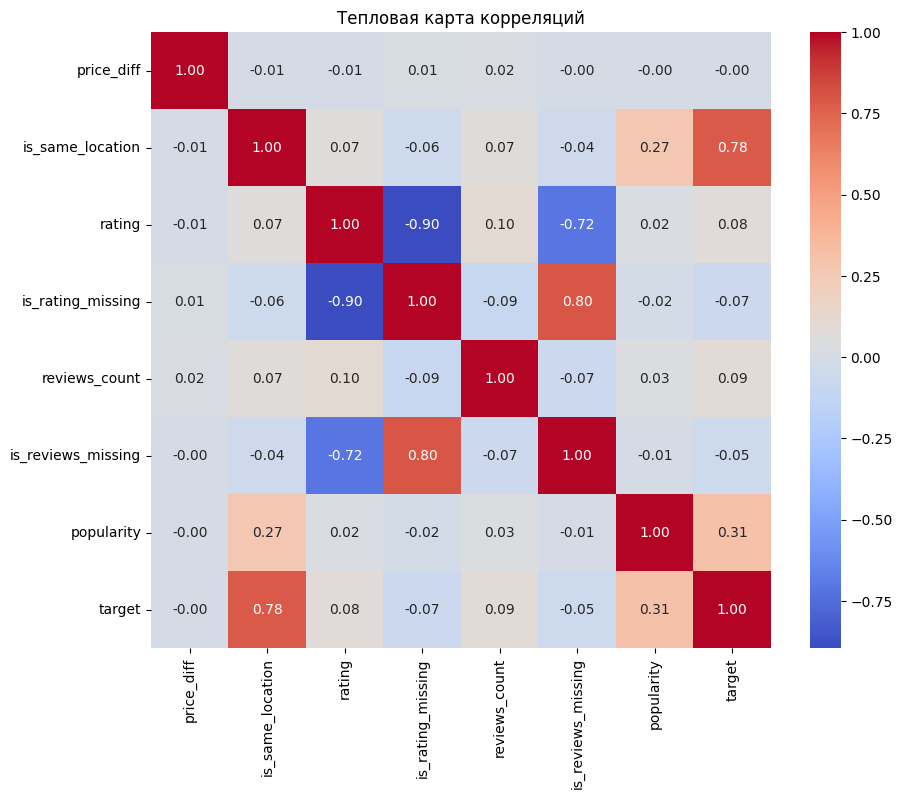

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
corr_matrix = df_train_final.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Тепловая карта корреляций")
plt.show()

In [21]:
from catboost import CatBoostClassifier
cat_features = ['is_same_location', 'is_rating_missing', 'is_reviews_missing']
final_model = CatBoostClassifier(iterations=300, depth=6, learning_rate=0.1, verbose=50, cat_features=cat_features)
features_to_drop = ['target']
X = df_train_final.drop(features_to_drop, axis=1)
final_model.fit(X, df_train_final['target'])

0:	learn: 0.3704649	total: 65.8ms	remaining: 19.7s
50:	learn: 0.0489071	total: 566ms	remaining: 2.76s
100:	learn: 0.0465979	total: 1.05s	remaining: 2.06s
150:	learn: 0.0445344	total: 1.55s	remaining: 1.53s
200:	learn: 0.0429661	total: 2.03s	remaining: 1s
250:	learn: 0.0412173	total: 2.54s	remaining: 496ms
299:	learn: 0.0398419	total: 3.02s	remaining: 0us


CatBoostClassifier(cat_features=['is_same_location', 'is_rating_missing', 'is_reviews_missing'], depth=6, iterations=300, learning_rate=0.1, verbose=50)

In [22]:
def get_answer_for_query(search_row):
    # Получаем 100 кандидатов
    tokenized_query = search_row['search_query'].lower().split()
    doc_scores = bm25.get_scores(tokenized_query)
    top_100_indices = np.argsort(doc_scores)[::-1][:100]
    candidate_ids = items.iloc[top_100_indices]['item_id'].values

    # Ранжируем
    features_list = []
    for cand_id in candidate_ids:
        features_list.append(get_features(search_row, items_dict.loc[cand_id], 0.5))

    X_test = pd.DataFrame(features_list)
    probs = final_model.predict_proba(X_test)[:, 1]

    # Выбираем топ-50
    top_50_idx = np.argsort(probs)[::-1][:50]
    return " ".join([candidate_ids[i] for i in top_50_idx])



In [23]:

answers = queries.apply(get_answer_for_query, axis=1)

result = pd.DataFrame({'query_id': queries['query_id'], 'answer': answers})
result.to_csv('answer.csv', index=False)

print("Файл answer.csv создан")

Файл answer.csv создан


In [24]:
def validate_answer(file_path, expected_query_ids):
    df = pd.read_csv(file_path)

    # Проверка колонок
    if list(df.columns) != ['query_id', 'answer']:
        return "Ошибка в колонках"

    # Проверка количества строк
    if len(df) != len(expected_query_ids):
        return f"Ошибка в числе строк"

    # Проверка ID запросов
    if not set(df['query_id']).issubset(set(expected_query_ids)):
        return "Ошибка в айди"

    #  Проверка содержимого
    for i, row in df.iterrows():
        items_list = str(row['answer']).split()


        if len(items_list) > 50:
            return f"В ответе больше 50 айди."


        if len(items_list) != len(set(items_list)):
            return f"Найдены дубликаты."


        for item_id in items_list:
            if len(item_id) != 16:
                return f"Формат."

    return "Пройдено"

print(validate_answer('answer.csv', queries['query_id'].tolist()))

Пройдено
